# Simple RNN with Layer Normalization

## 1 Data

In [1]:
from load_data import load_data

dataset = load_data()

single_step :
   X :
     train :  (7000, 41, 1)
     valid :  (2000, 41, 1)
     test :  (1000, 41, 1)
   Y :
     train :  (7000, 41, 10)
     valid :  (2000, 41, 10)
     test :  (1000, 41, 10)
multi_horizon :
   X :
     train :  (7000, 41, 1)
     valid :  (2000, 41, 1)
     test :  (1000, 41, 1)
   Y :
     train :  (7000, 41, 10)
     valid :  (2000, 41, 10)
     test :  (1000, 41, 10)
sequence :
   X :
     train :  (7000, 41, 1)
     valid :  (2000, 41, 1)
     test :  (1000, 41, 1)
   Y :
     train :  (7000, 41, 10)
     valid :  (2000, 41, 10)
     test :  (1000, 41, 10)


## 2 Model

### 2.1 Layer

In [2]:
import tensorflow as tf
from typing import Dict, Sequence


class LNSimpleRNNCell(tf.keras.layers.SimpleRNNCell):
    def __init__(self, units: int, activation: str = "tanh", **kwargs):
        super().__init__(units, None, **kwargs)
        self.layer_norm = tf.keras.layers.LayerNormalization()
        self.activation = tf.keras.activations.get(activation)

    def call(self, inputs: Sequence[Sequence[float]], states: Sequence[Sequence[float]]) -> tf.Tensor:
        outputs = self.activation(self.layer_norm(super().call(inputs, states)[0]))
        return outputs, [outputs]

    def compute_output_shape(self, batch_input_shape: tf.TensorShape):
        return tf.TensorShape(batch_input_shape.as_list()[:-1] + [self.units])

    def get_config(self) -> Dict[str, str]:
        return {
            **super().get_config(),
            "activation": tf.keras.activations.serialize(self.activation),
        }

2023-02-05 14:13:31.070792: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


### 2.2 Model

In [3]:
def mse_last_time_step(y_true: tf.Tensor, y_pred: tf.Tensor) -> tf.Tensor:
    return tf.keras.metrics.mean_squared_error(y_true[:, -1], y_pred[:, -1])

In [4]:
model = tf.keras.models.Sequential([
    tf.keras.layers.RNN(LNSimpleRNNCell(20), return_sequences=True, input_shape=(None, 1)),
    tf.keras.layers.RNN(LNSimpleRNNCell(20), return_sequences=True),
    tf.keras.layers.Dense(10)
])
model.compile(optimizer="adam", loss="mse", metrics=mse_last_time_step)
model.summary()

2023-02-05 14:13:33.832183: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-02-05 14:13:33.870335: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-02-05 14:13:33.871970: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-02-05 14:13:33.872770: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropri

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rnn (RNN)                   (None, None, 20)          480       
                                                                 
 rnn_1 (RNN)                 (None, None, 20)          860       
                                                                 
 dense (Dense)               (None, None, 10)          210       
                                                                 
Total params: 1,550
Trainable params: 1,550
Non-trainable params: 0
_________________________________________________________________


## 3 Training

In [5]:
import time
from pathlib import Path

epochs = 100
root_logdir = Path().absolute() / "logs"
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
tensorboard_cb = tf.keras.callbacks.TensorBoard(root_logdir / time.strftime("%Y_%m_%d-%H_%M_%S_rnn_sts"))

%load_ext tensorboard
%tensorboard --logdir=./logs --port=6006

Launching TensorBoard...

In [6]:
history = model.fit(dataset["sequence"]["X"]["train"], dataset["sequence"]["Y"]["train"], validation_data=(dataset["sequence"]["X"]["valid"], dataset["sequence"]["Y"]["valid"]), epochs=epochs, callbacks=[early_stopping_cb, tensorboard_cb])

Epoch 1/100


2023-02-05 14:13:40.446387: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8401


219/219 [==============================] - 29s 122ms/step - loss: 0.1762 - mse_last_time_step: 0.1512 - val_loss: 0.0932 - val_mse_last_time_step: 0.0866
Epoch 2/100
219/219 [==============================] - 28s 128ms/step - loss: 0.0603 - mse_last_time_step: 0.0526 - val_loss: 0.0396 - val_mse_last_time_step: 0.0329
Epoch 3/100
219/219 [==============================] - 34s 155ms/step - loss: 0.0387 - mse_last_time_step: 0.0285 - val_loss: 0.0371 - val_mse_last_time_step: 0.0304
Epoch 4/100
219/219 [==============================] - 26s 117ms/step - loss: 0.0298 - mse_last_time_step: 0.0185 - val_loss: 0.0251 - val_mse_last_time_step: 0.0138
Epoch 5/100
219/219 [==============================] - 26s 118ms/step - loss: 0.0241 - mse_last_time_step: 0.0135 - val_loss: 0.0218 - val_mse_last_time_step: 0.0131
Epoch 6/100
219/219 [==============================] - 26s 119ms/step - loss: 0.0216 - mse_last_time_step: 0.0117 - val_loss: 0.0197 - val_mse_last_time_step: 0.0113
Epoch 7/100
219/

In [9]:
# Save model
dir_models = Path() / "models"
model.save(dir_models / "model_rnn_ln")

INFO:tensorflow:Assets written to: models/model_rnn_ln/assets


INFO:tensorflow:Assets written to: models/model_rnn_ln/assets


## 4 Evaluation

In [10]:
import numpy as np

i_ts = 1
x = dataset["sequence"]["X"]["test"][i_ts, :]
y_true = dataset["sequence"]["Y"]["test"][i_ts][-1, :]
y_pred = model.predict(x[np.newaxis, :, :])[0, -1]

1/1 [==============================] - 0s 32ms/step


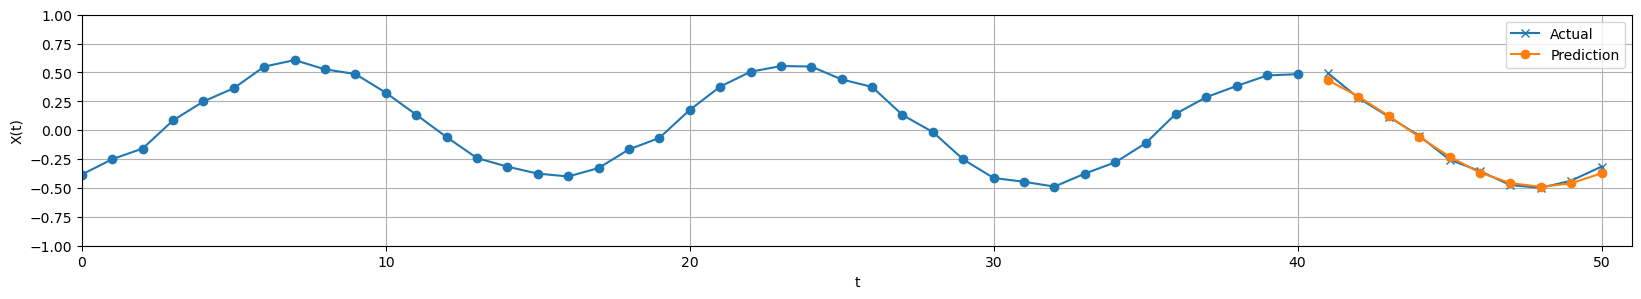

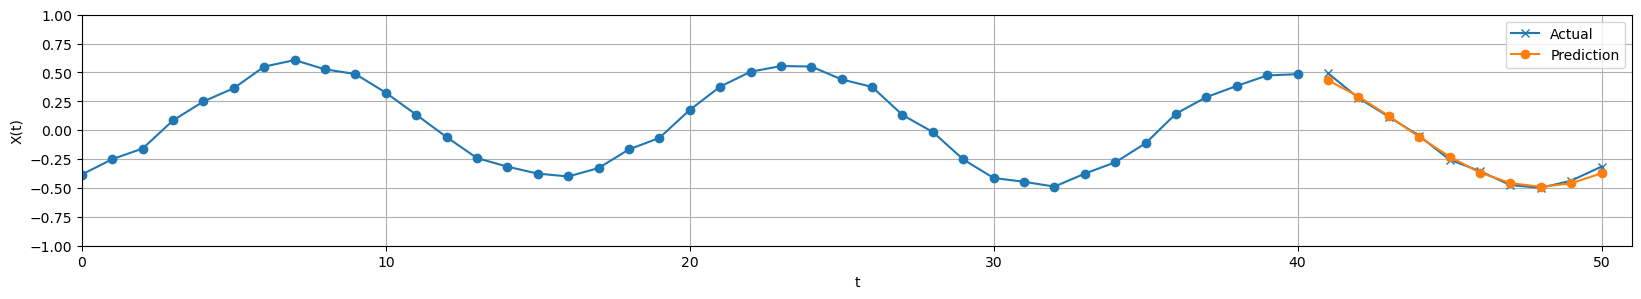

In [11]:
from plot import plot

plot(series=x[:, 0], y_true=y_true, y_pred=y_pred)